# Investigate the MAE distribution of sampled configurations of molecules

In [54]:
import importlib
import os
import sys
import statistics

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

import helper
from modelforge.dataset.dataset import initialize_datamodule
from modelforge.dataset.utils import RandomRecordSplittingStrategy, SplittingStrategy

sns.set_theme()
sns.set_context("notebook")
%matplotlib inline

## Load an AIMNet2 model checkpoint

In [55]:
from modelforge.potential.potential import load_inference_model_from_checkpoint

# Helper utilities to load the example model checkpoint bundled with modelforge.
from modelforge.utils.io import get_path_string
# from modelforge.ase.tests import data

checkpoint_file_path = f"trained_potentials/AIMNet2_tmQMOpenFF_full.ckpt" # This is an example model used in testing 
potential = load_inference_model_from_checkpoint(checkpoint_file_path, jit=False)
print(f"Loaded checkpoint: {checkpoint_file_path}")

2026-07-13 11:01:47.984 | DEBUG    | modelforge.potential.potential:generate_potential:889 - training_parameter=None
2026-07-13 11:01:47.985 | DEBUG    | modelforge.potential.potential:generate_potential:890 - potential_parameter=AimNet2Parameters(potential_name='AimNet2', only_unique_pairs=False, core_parameter=CoreParameter(number_of_radial_basis_functions=64, maximum_interaction_radius=0.49999999999999994, number_of_interaction_modules=3, interaction_module_hidden_layers=[[512, 256], [512, 256], [512, 256, 256]], output_module_hidden_layers=[128, 128], activation_function_parameter=ActivationFunctionConfig(activation_function_name='GeLU', activation_function_arguments=None, activation_function=GELU(approximate='none')), featurization=Featurization(properties_to_featurize=['atomic_number', 'per_system_total_charge', 'per_system_spin_state'], atomic_number=AtomicNumber(maximum_atomic_number=101, number_of_per_atom_features=512), atomic_period=AtomicPeriod(maximum_period=8, number_of_p

Loaded checkpoint: trained_potentials/AIMNet2_tmQMOpenFF_full.ckpt


## Load the tmQM-OpenFF dataset

In [56]:
# initialize datasets as in training
dm = initialize_datamodule(
    dataset_name="tmqm_openff_local",
    version_select="full_dataset_v1.4c",
    splitting_strategy=RandomRecordSplittingStrategy(
            seed=42,
            split=[0.8, 0.1, 0.1],
        ),
    local_cache_dir="../cache",
    batch_size=1,
    dataset_cache_dir="./dataset_cache",
    local_yaml_file = "/Users/syan/workdir/modelforge-experiments/experiments/exp12/cache/tmqm-openff_ext/tmqm_openff_local.yaml", #note, this should in general be the full path to the yaml file,
                                                        #but for testing purposes on CI, we need to use a placeholder
                                                        #i.e., path_to_file, which the test will replace.
    properties_of_interest= ["atomic_numbers", "positions", "dft_total_energy", "scf_dipole", "total_charge", "lowdin_partial_charges", "per_system_spin_multiplicity", "dft_total_force"],
    properties_assignment={
        "atomic_numbers": "atomic_numbers",
        "positions": "positions",
        "E": "dft_total_energy",
        "F": "dft_total_force",
        "total_charge": "total_charge",
        "dipole_moment": "scf_dipole",
        "partial_charges": "lowdin_partial_charges",
        "spin_multiplicity": "per_system_spin_multiplicity",
    }
)

2026-07-13 11:01:50.520 | DEBUG    | modelforge.dataset.dataset:__init__:350 - Loading config data from user specified file: /Users/syan/workdir/modelforge-experiments/experiments/exp12/cache/tmqm-openff_ext/tmqm_openff_local.yaml
2026-07-13 11:01:50.527 | INFO     | modelforge.dataset.dataset:__init__:379 - Using dataset version full_dataset_v1.4c
2026-07-13 11:01:50.528 | DEBUG    | modelforge.dataset.dataset:_acquire_dataset:437 - Unzipped npz file tmqm_openff_local.npz already exists in ../cache
2026-07-13 11:01:50.529 | DEBUG    | modelforge.dataset.dataset:_from_file_cache:1105 - Loading processed data from ../cache/tmqm_openff_local.npz generated on 2026-06-25 11:31:29.092739
2026-07-13 11:01:50.530 | DEBUG    | modelforge.dataset.dataset:_from_file_cache:1108 - Properties of Interest in .npz file: ['atomic_numbers', 'dft_total_energy', 'scf_dipole', 'total_charge', 'per_system_spin_multiplicity', 'positions', 'lowdin_partial_charges', 'dft_total_force']
2026-07-13 11:01:50.531 

Validating file ../cache/tmqm_openff_local.npz


2026-07-13 11:01:51.133 | INFO     | modelforge.dataset.dataset:_calculate_atomic_self_energies:1470 - Using atomic self energies provided by the dataset.
2026-07-13 11:01:51.133 | DEBUG    | modelforge.dataset.dataset:prepare_data:1367 - Process dataset ...
2026-07-13 11:01:51.133 | INFO     | modelforge.dataset.dataset:_per_datapoint_operations:1565 - Performing per datapoint operations in the dataset
2026-07-13 11:01:51.133 | INFO     | modelforge.dataset.dataset:_per_datapoint_operations:1567 - Removing self energies from the dataset
Calculating pairlist for dataset: 100%|██████████| 4076/4076 [00:29<00:00, 138.70it/s]
2026-07-13 11:02:33.011 | INFO     | modelforge.dataset.utils:calculate_mean_and_variance:167 - Calculating mean and variance of atomic energies
100%|██████████| 1592/1592 [00:11<00:00, 140.09it/s]
2026-07-13 11:02:44.378 | INFO     | modelforge.dataset.utils:calculate_mean_and_variance:179 - Mean and standard deviation of the dataset:{'per_atom_energy_mean': tensor(

### Use data module

In [57]:
dm.test_dataset.dataset.properties_of_interest["partial_charges"].shape

torch.Size([45473136, 1])

In [49]:
from typing import List
from modelforge.utils.prop import BatchData, NNPInput, Metadata

def collate_conformers(conf_list: List[BatchData]) -> BatchData:
    """
    Collate a list of BatchData instances into a single BatchData instance.

    Parameters
    ----------
    conf_list : List[BatchData]
        List of BatchData instances.

    Returns
    -------
    BatchData
        Collated batch data.
    """
    atomic_numbers_list = []
    positions_list = []
    total_charge_list = []
    S_list = []
    E_list = []  # total energy
    F_list = []  # forces
    ij_list = []
    dipole_moment_list = []
    quadrupole_moment_list = []
    per_atom_charge_list = []
    per_atom_spin_multiplicity_list = []
    atomic_subsystem_counts_list = []
    atomic_subsystem_indices_referencing_dataset_list = []

    offset = torch.tensor([0], dtype=torch.int32)
    pair_list_present = (
        True
        if hasattr(conf_list[0].nnp_input, "pair_list")
        and isinstance(conf_list[0].nnp_input.pair_list, torch.Tensor)
        else False
    )

    for conf in conf_list:
        if pair_list_present:
            ## pairlist
            # generate pairlist without padded values
            pair_list = conf.nnp_input.pair_list.to(dtype=torch.int32) + offset
            # update offset (for making sure the pair_list indices are pointing to the correct molecule)
            offset += conf.nnp_input.atomic_numbers.shape[0]
            ij_list.append(pair_list)

        atomic_numbers_list.append(conf.nnp_input.atomic_numbers)
        positions_list.append(conf.nnp_input.positions)
        total_charge_list.append(conf.nnp_input.per_system_total_charge)
        dipole_moment_list.append(conf.metadata.per_system_dipole_moment)
        quadrupole_moment_list.append(conf.metadata.per_system_quadrupole_moment)
        per_atom_charge_list.append(conf.metadata.per_atom_charge)
        per_atom_spin_multiplicity_list.append(conf.metadata.per_atom_spin_multiplicity)

        E_list.append(conf.metadata.per_system_energy)
        F_list.append(conf.metadata.per_atom_force)
        S_list.append(conf.nnp_input.per_system_spin_state)
        atomic_subsystem_counts_list.append(conf.metadata.atomic_subsystem_counts)
        atomic_subsystem_indices_referencing_dataset_list.append(
            conf.metadata.atomic_subsystem_indices_referencing_dataset
        )

    atomic_subsystem_counts = torch.cat(atomic_subsystem_counts_list)
    atomic_subsystem_indices = torch.repeat_interleave(
        torch.arange(len(conf_list), dtype=torch.int32), atomic_subsystem_counts
    )
    atomic_subsystem_indices_referencing_dataset = torch.cat(
        atomic_subsystem_indices_referencing_dataset_list
    )
    atomic_numbers = torch.cat(atomic_numbers_list)
    total_charge = torch.stack(total_charge_list).to(torch.float32)
    positions = torch.cat(positions_list).requires_grad_(True)
    F = torch.cat(F_list).to(torch.float64)
    dipole_moment = torch.stack(dipole_moment_list).to(torch.float32)
    quadrupole_moment = torch.stack(quadrupole_moment_list).to(torch.float32)
    per_atom_charge = torch.cat(per_atom_charge_list).to(torch.float32)
    per_atom_spin_multiplicity = torch.cat(per_atom_spin_multiplicity_list).to(
        torch.float32
    )
    E = torch.stack(E_list)
    spin_multiplicity = torch.cat(S_list).to(torch.float32)
    if pair_list_present:
        IJ_cat = torch.cat(ij_list, dim=1).to(torch.int64)
    else:
        IJ_cat = None

    nnp_input = NNPInput(
        atomic_numbers=atomic_numbers,
        positions=positions,
        per_system_total_charge=total_charge,
        atomic_subsystem_indices=atomic_subsystem_indices,
        per_system_spin_state=spin_multiplicity,
        pair_list=IJ_cat,
        per_atom_partial_charge=per_atom_charge,
    )
    metadata = Metadata(
        per_system_energy=E,
        per_atom_force=F,
        atomic_subsystem_counts=atomic_subsystem_counts,
        atomic_subsystem_indices_referencing_dataset=atomic_subsystem_indices_referencing_dataset,
        number_of_atoms=atomic_numbers.numel(),
        per_system_dipole_moment=dipole_moment,
        per_atom_charge=per_atom_charge,
        per_system_quadrupole_moment=quadrupole_moment,
        per_atom_spin_multiplicity=per_atom_spin_multiplicity,
    )

    return BatchData(nnp_input, metadata)


# from modelforge.dataset.dataset import DatasetFactory
from modelforge.dataset.utils import (
    FirstComeFirstServeSplittingStrategy,
    SplittingStrategy,
)

In [50]:
import modelforge
from torch.utils.data import DataLoader

test_dataloader = DataLoader(
            dm.test_dataset,
            batch_size=1,
            collate_fn=collate_conformers,
            num_workers=4,
            multiprocessing_context="fork",
)


In [51]:
batch = next(iter(test_dataloader))

In [52]:
batch.nnp_input.per_atom_partial_charge

tensor([[-0.6628],
        [ 0.7730],
        [-0.2575],
        [ 0.2479],
        [-0.2121],
        [ 0.2731],
        [-0.2492],
        [ 0.2538],
        [-0.2495],
        [ 0.2519],
        [-0.4043],
        [ 0.1273],
        [ 0.1322],
        [ 0.1283],
        [-0.4031],
        [ 0.1279],
        [ 0.1320],
        [ 0.1273],
        [-0.2350],
        [-0.1268],
        [ 0.1499],
        [-0.1312],
        [ 0.1481],
        [-0.1293],
        [ 0.1470],
        [-0.1313],
        [ 0.1482],
        [-0.1255],
        [ 0.1498]])

In [25]:
test_dataloader = dm.test_dataloader()

In [12]:
dir(batch.nnp_input)

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '_validate_inputs',
 'atomic_numbers',
 'atomic_subsystem_indices',
 'box_vectors',
 'is_periodic',
 'pair_list',
 'per_atom_partial_charge',
 'per_system_spin_state',
 'per_system_total_charge',
 'positions',
 'to_device',
 'to_dtype']

In [58]:
predictions = []
with torch.no_grad():  # Disable gradient tracking to save memory
    for batch in test_dataloader:
        nnp_output = potential(batch.nnp_input)
        predictions.append(nnp_output)
        break

In [9]:
torch.save(predictions, "predictions.pt")

Task was destroyed but it is pending!
task: <Task pending name='Task-116' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/syan/miniforge3/envs/modelforge/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-117' coro=<Kernel.shell_main() running at /Users/syan/miniforge3/envs/modelforge/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/syan/miniforge3/envs/modelforge/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/syan/miniforge3/envs/modelforge/lib/python3.12/copyreg.py:107: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def _slotnames(cls):
Task was destroyed but it is pending!
task: <Task pending name='Task-117' coro=<Kernel.shell_main() running at /Users/syan/miniforge3/envs/modelforge/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


In [5]:
predictions = torch.load("predictions.pt")
len(predictions)

79806

In [14]:
predictions[0]["per_system_energy"]

tensor([[-213.5530]])

In [15]:
predictions[0]["atomic_numbers"]

tensor([26, 15,  6,  8,  6,  8,  6,  8,  6,  8,  6,  1,  1,  1,  6,  1,  1,  1,
         6,  6,  1,  6,  1,  6,  1,  6,  1,  6,  1], dtype=torch.int32)

In [102]:
atomic_numbers = []
true_per_system_energy = []
per_system_total_charge = []
per_system_spin_state = []
predicted_energy = []
with torch.no_grad():  # Disable gradient tracking to save memory
    for i, batch in enumerate(test_dataloader):
        atomic_numbers.append(
            str(predictions[i]["atomic_numbers"].tolist())
        )
        true_per_system_energy.append(batch.metadata.per_system_energy.item())
        per_system_total_charge.append(batch.nnp_input.per_system_total_charge.item())
        per_system_spin_state.append(batch.nnp_input.per_system_spin_state.item())
        predicted_energy.append(predictions[i]["per_system_energy"].item())

In [100]:
batch.nnp_input.per_system_total_charge

tensor([[0.]])

In [104]:
def group_record_indices(predictions):
    record_index_collections = []
    j = 0
    for i, configuration in enumerate(predictions):
        if i == 0:
            record_index_collections.append(
                {
                    "index": [0],
                    # "predictions": [predictions[0]],
                    # "true_per_system_energy": [true_per_system_energy[0]],
                    # "per_system_spin_state": [per_system_spin_state[0]],
                }
            )
        else:
            if predictions[i]["atomic_numbers"].shape[0] == predictions[i - 1]["atomic_numbers"].shape[0]:
                if torch.all(torch.eq(predictions[i]["atomic_numbers"], predictions[i - 1]["atomic_numbers"])):
                    record_index_collections[j]["index"].append(i)
                    # record_collections[j]["predictions"].append(predictions[i])
                    # record_collections[j]["true_per_system_energy"].append(true_per_system_energy[i])
                    # record_collections[j]["per_system_spin_state"].append(per_system_spin_state[i])
            else:
                j += 1  # create next record
                record_index_collections.append(
                    {
                        "index": [i],
                        # "predictions": [predictions[i]],
                        # "true_per_system_energy": [true_per_system_energy[i]],
                        # "per_system_spin_state": [per_system_spin_state[i]],
                    }
                )

    return record_index_collections

In [105]:
record_index_collections = group_record_indices(predictions)

In [107]:
len(record_index_collections)

1866

In [109]:
df = pd.DataFrame(
    {
        "atomic_numbers": atomic_numbers,
        "per_system_total_charge": per_system_total_charge,
        "per_system_spin_state": per_system_spin_state,
        "predicted_energy": predicted_energy,
        "true_per_system_energy": true_per_system_energy,
        "errors": np.array(predicted_energy) - np.array(true_per_system_energy),
    }
)

In [123]:
df[:10]

,atomic_numbers,per_system_total_charge,per_system_spin_state,predicted_energy,true_per_system_energy,errors
0,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,1.0,-213.552979,-478.663016,265.110038
1,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,3.0,-41.719406,-151.343364,109.623958
2,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,5.0,151.275696,203.480220,-52.204524
3,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,1.0,-200.953278,-460.845454,259.892176
4,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,3.0,-47.498245,-154.530202,107.031957
5,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,5.0,135.804382,187.045205,-51.240823
6,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,1.0,-174.033997,-441.079343,267.045347
7,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,3.0,-8.533859,-130.452969,121.919109
8,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,5.0,173.724426,222.600021,-48.875594
9,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,1.0,-184.587860,-449.081093,264.493233


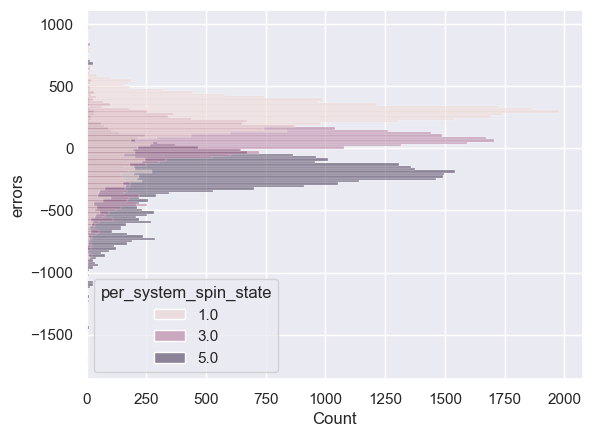

In [92]:
sns.histplot(df, y="errors", hue="per_system_spin_state")
plt.show()

In [108]:
n_records = 15
n_rows = record_index_collections[n_records - 1]["index"][-1]

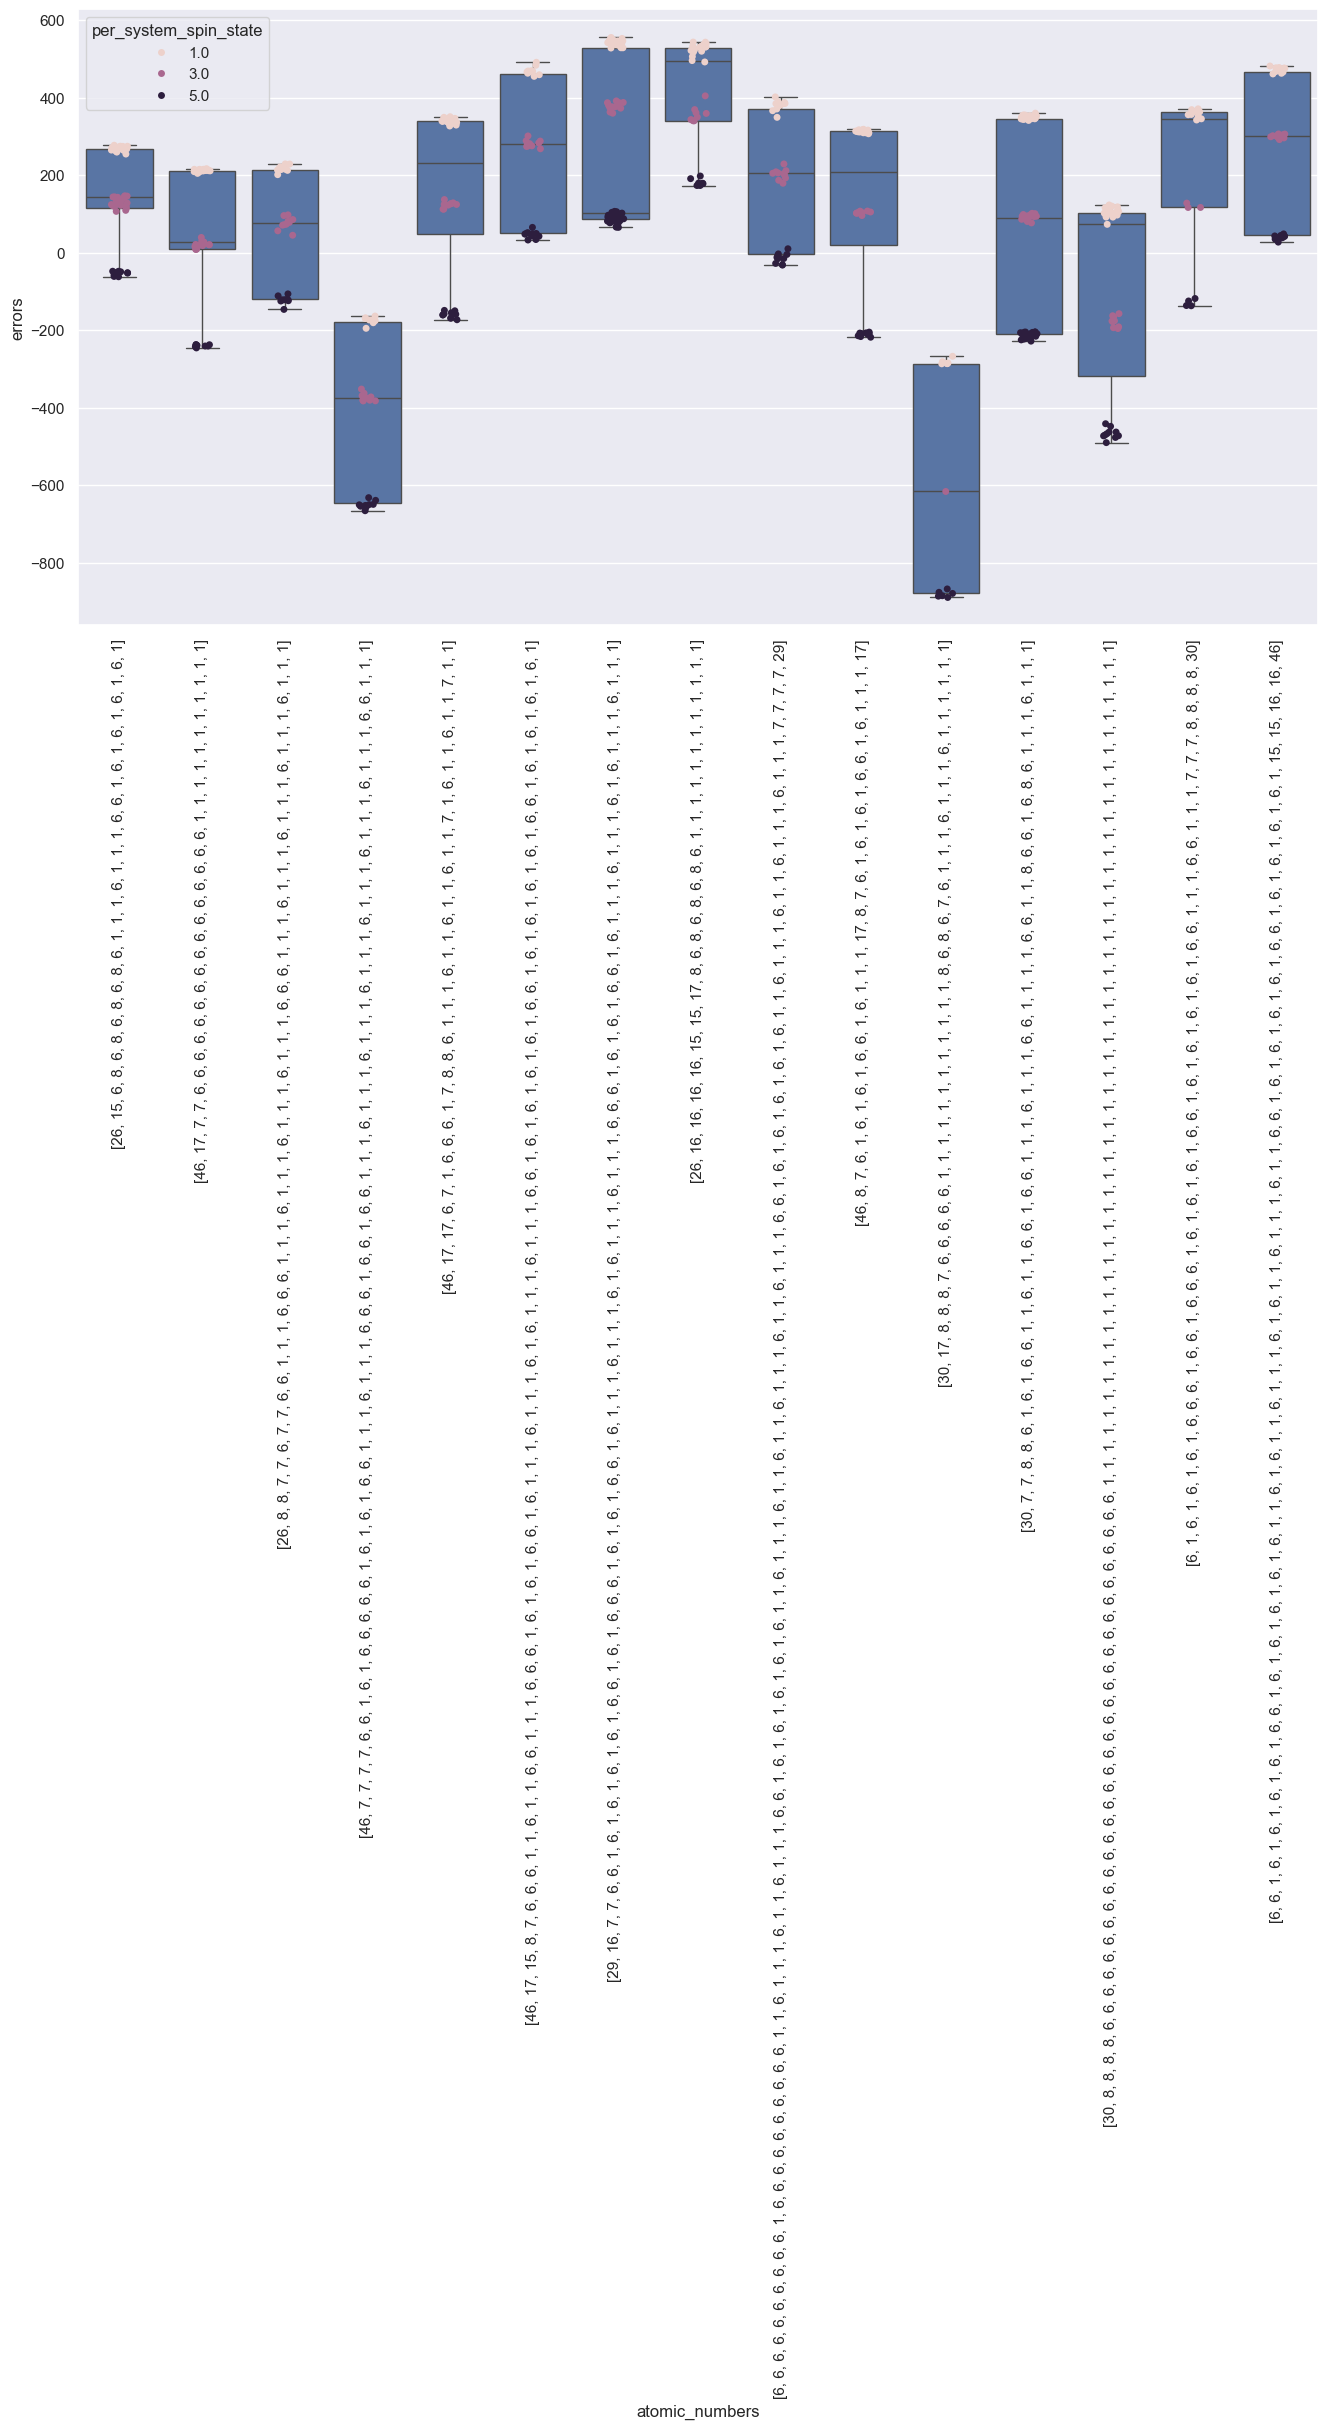

In [94]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df[:n_rows], x="atomic_numbers", y="errors",)
sns.stripplot(data=df[:n_rows], x="atomic_numbers", y="errors", hue="per_system_spin_state")

plt.xticks(rotation='vertical')
plt.show()

In [4]:
dm.torch_dataset[0]

BatchData(nnp_input=<modelforge.utils.prop.NNPInput object at 0x35e5e2340>, metadata=<modelforge.utils.prop.Metadata object at 0x35e5e26c0>)

In [6]:
with torch.no_grad():  # Disable gradient tracking to save memory
    for i, batch in enumerate(dm.torch_dataset):
        if batch.nnp_input.per_system_total_charge.item() != 0:
            print(i)
            if i > 100000:
                break

178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
956
957
958
959
960
961
962
963
964
965
966
967
968
969
970
971
972
973
974
975
976
977
978
979
980
981
982
983
984
985
986
987
988
989
990
991
992
993
994
995
996
997
998
999
1000
1001
1002
1003
1004
1005
1006
1007
1008
1009
1010
1011
1012
1013
1014
1015
1016
1017
1018
1019
1020
1021
1022
1023
1024
1025
1026
1027
1028
1029
1030
1031
1181
1182
1183
1184
1185
1186
1187
1188
1189
1190
1191
1192
1193
1194
1195
1196
1197
1198
1199
1200
1201
1202
1203
1204
1205
1206
1207
1208
1209
1210
1211
1212
1213
1214
1215
1216
1217
1218
1219
1220
1221
1222
1223
1224
1225
1226
1227
1228
1229
1230
1231
1232
1233
1234
1235
1236
1237
1238
1239
1240
1241
1242
1243
1244
1245
1246
1247
1248
1249
1250
1251
1252
1253
1254
1255
1256
1297
1298
1299
1300
1301
1302
1303
1304
1305
1306
13

In [127]:
batch.nnp_input.per_system_total_charge.item()

0